#  Prétraitement des Données

Tests et visualisation des étapes de prétraitement : nettoyage, normalisation, création de masques, découpage en patchs, augmentation.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys,os
# Ajouter src au chemin de recherche des modules
notebook_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
	sys.path.append(src_path)
import image_search,pretraitement_cnn
from tqdm import tqdm # barre de progression



# Preprocessing for Model from scratch 

Nous allons redimentionner tous les images dans le format 256x256 .
De base les images sont pris dans des contextes trés varié, pour certains images,le chient ne represente qu'une toute petite portion,aussi nous avons decider d'utuliser les bounding-box pour recadrer les images puis completer par un padding afin d'obtenir une imagede taille 255x255

## A quoi ressemble nos images avant et aprés ?

In [42]:
df_imgs=image_search.index_dataset(r"..\data\images",)

In [44]:
df_imgs['class'].values

array(['n02085620-Chihuahua', 'n02085620-Chihuahua',
       'n02085620-Chihuahua', ..., 'n02116738-African_hunting_dog',
       'n02116738-African_hunting_dog', 'n02116738-African_hunting_dog'],
      dtype=object)

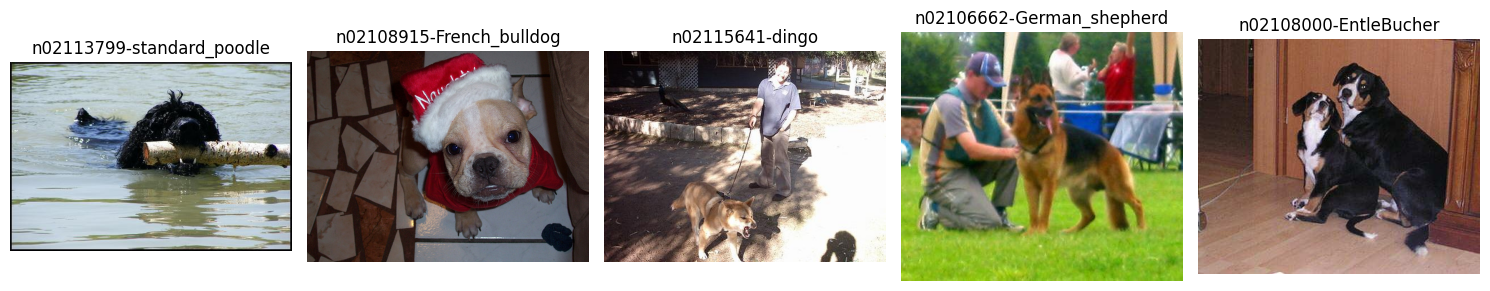

In [45]:
sample=df_imgs.sample(n=6)
image_search.show_images(sample)

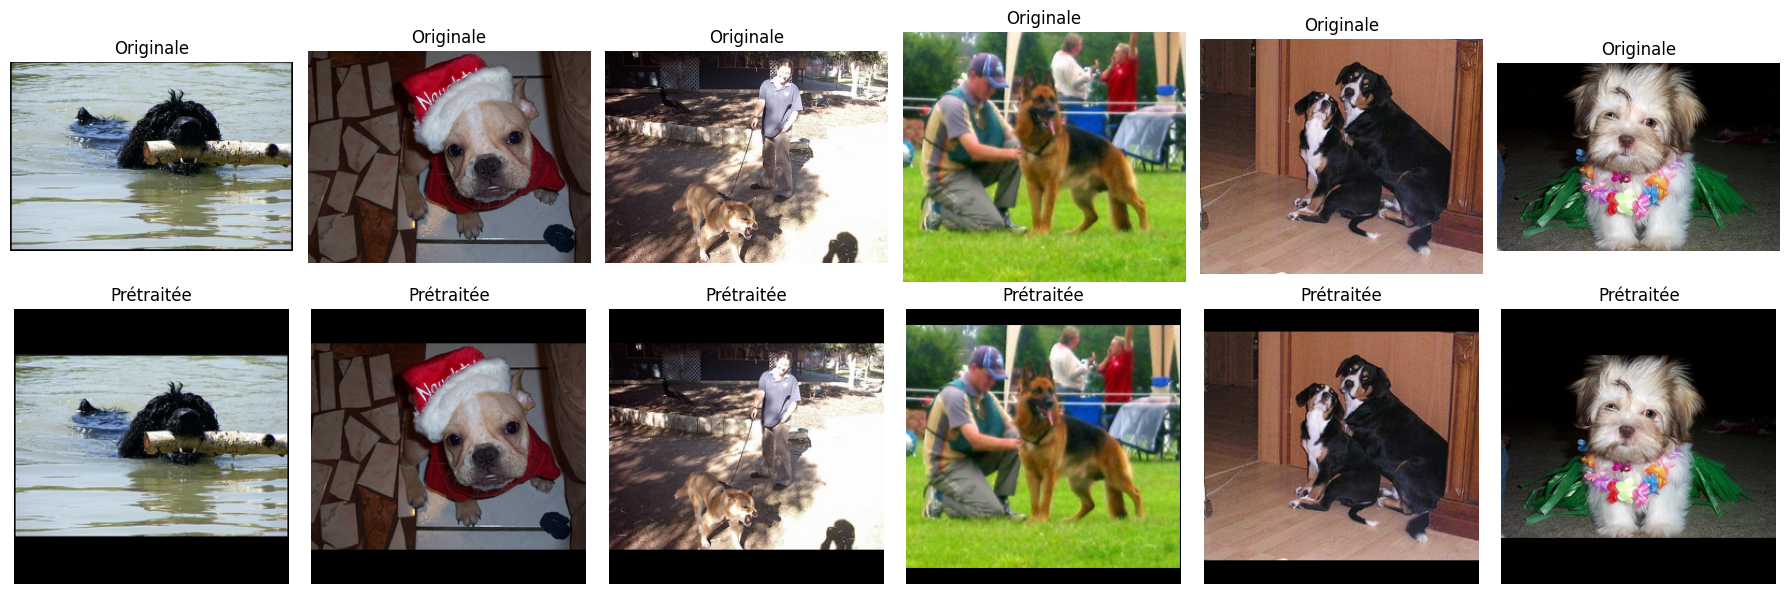

In [46]:
n_images = len(sample)
fig, axs = plt.subplots(2, n_images, figsize=(3*n_images, 6))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row['image_path'])
    axs[0, i].imshow(img)
    axs[0, i].set_title("Originale")
    axs[0, i].axis('off')
    
    img_prep = pretraitement_cnn.resize_with_padding(
        img,
   
    )
    axs[1, i].imshow(img_prep)
    axs[1, i].set_title("Prétraitée")
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()

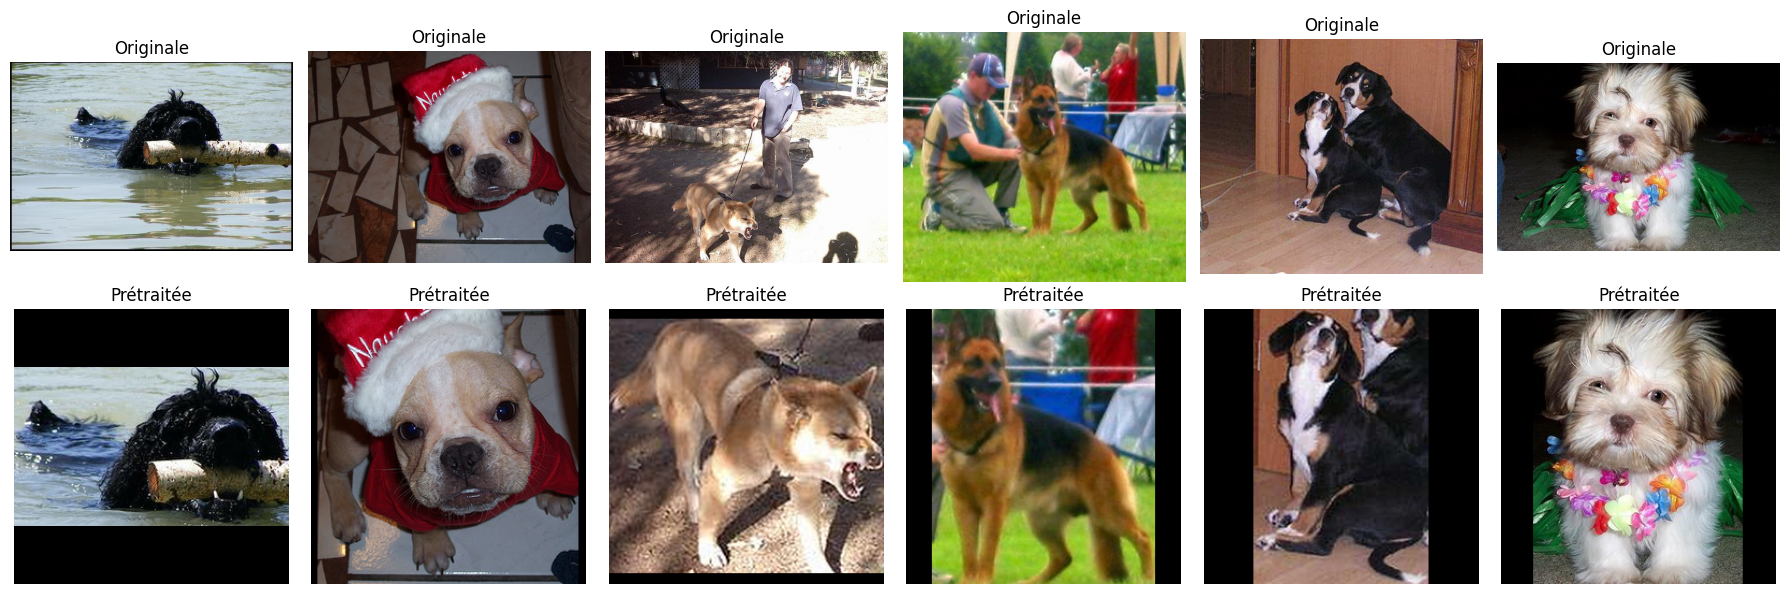

In [47]:
fig, axs = plt.subplots(2, n_images, figsize=(3*n_images, 6))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row['image_path'])
    axs[0, i].imshow(img)
    axs[0, i].set_title("Originale")
    axs[0, i].axis('off')
    
    img_prep = pretraitement_cnn.recadrer_selon_bbox(
        img,
        img_path=row['image_path'],
        annotation_dir="../data/annotation" 
    )
    axs[1, i].imshow(img_prep)
    axs[1, i].set_title("Prétraitée")
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()

Nous avons bien des images 256x256 avec un focus sur le chien.
Le padding n'est peut-etre pas une bonne idée, on ne le saura qu'aprés avoir entrainé le modele,au mieux on peut faire des rotations et des zomes et esperer corriger ce biais.Sinon,une autre solution serais d'etirer les images afin d'occuper toute l'espace.

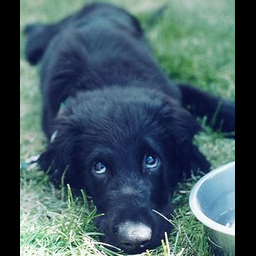

In [40]:
img_prep.size 
img_prep

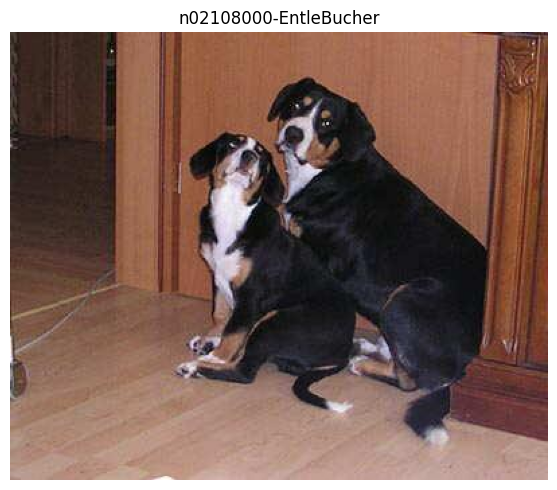

In [52]:
image_search.show_images(sample.iloc[[4]])

> une image avec plusieurs chiens, a-ton plusieurs boites ?

a priori non,mais  si cela s'avere le cas tel que nous avons ecrit notre fonction `recadrer_selon_bbox`elle ne conservera que le premier chien . Comme ce processus sera appliqué à tous les images (train comme test),le modele ne verra jamais plusieurs chiens, tous se passera bien car apres tout une image, meme si elle montre plusieurs chiens ce sera nécessairement de la même race.

## Generation d'un nouveau dataset prétraité

In [58]:
# teste avec un seul image

row = df_imgs.sample(n=1).iloc[0] # Sélection d'une image au hasard
img_path = row['image_path']
img = Image.open(img_path)

img_prep = pretraitement_cnn.recadrer_selon_bbox(
    img,
    img_path=img_path,
    annotation_dir="../data/annotation"
)

output_dir = "../data/teste_transf"
rel_path = os.path.relpath(img_path, "../data/images")
save_path = os.path.join(output_dir, rel_path)
os.makedirs(os.path.dirname(save_path), exist_ok=True)
img_prep.save(save_path)

In [ ]:


output_dir = "../data/images_transf_256x256"

for _, row in tqdm(df_imgs.iterrows(), total=len(df_imgs)):
    img_path = row['image_path']
    img = Image.open(img_path)
    img_prep = pretraitement_cnn.recadrer_selon_bbox(
        img,
        img_path=img_path,
        annotation_dir="../data/annotation"
    )
    rel_path = os.path.relpath(img_path, "../data/images")
    save_path = os.path.join(output_dir, rel_path)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    img_prep.save(save_path)

 86%|████████▌ | 17749/20580 [6:32:41<4:51:38,  6.18s/it]     